# Irish Property Price Register — Complete Analysis (2010–2026)

**Dataset:** Every residential property sale recorded in Ireland from 2010 to 2026 — 778,000+ transactions, cleaned from the Revenue Commissioners Property Price Register into one flat CSV.

**Author:** Fionn Hughes

---

## What this notebook covers

1. **Data Overview** — shape, dtypes, missing values
2. **National Price Trends** — how median prices moved year by year since 2010
3. **The Crash & Recovery** — visualising the full property cycle
4. **County-by-County Breakdown** — which counties are most expensive, cheapest, fastest-growing
5. **Dublin vs The Rest** — the capital premium over time
6. **New Builds vs Second-Hand** — price gap, market share, VAT effects
7. **COVID Impact** — what happened to transaction volumes and prices in 2020–2021
8. **Seasonal Patterns** — which month sees the most sales and highest prices
9. **Eircode Analysis** — drilling into Dublin postcode areas
10. **Affordability Proxy** — tracking price-to-income ratio using CSO wage data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# --- Style ---
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#333',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#222',
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

ACCENT   = '#f5a623'
BLUE     = '#4a9eff'
GREEN    = '#2ecc71'
RED      = '#e74c3c'
PURPLE   = '#9b59b6'

def fmt_eur(x, pos=None):
    return f'€{x/1000:.0f}k'

print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Overview

In [2]:
df = pd.read_csv(
    '/kaggle/input/datasets/fionnhughes/property-price-register/property_price_register.csv',
    low_memory=False
)

# Explicitly parse after loading
df['date_of_sale'] = pd.to_datetime(df['date_of_sale'], dayfirst=True, errors='coerce')

# Drop rows where date failed to parse
df = df.dropna(subset=['date_of_sale'])

# Derived columns used throughout
df['year']    = df['date_of_sale'].dt.year
df['month']   = df['date_of_sale'].dt.month
df['quarter'] = df['date_of_sale'].dt.to_period('Q')
df['is_dublin'] = df['county'].str.lower() == 'dublin'
df['is_new']    = df['vat_exclusive'].astype(bool)

# Drop clear outliers
df = df[(df['price_eur'] >= 10_000) & (df['price_eur'] <= 20_000_000)]

print(f'Rows:     {len(df):,}')
print(f'Columns:  {df.shape[1]}')
print(f'Date range: {df["date_of_sale"].min().date()} → {df["date_of_sale"].max().date()}')

Rows:     284,817
Columns:  14
Date range: 2010-01-01 → 2026-12-03


In [3]:
# Price distribution snapshot
stats = df['price_eur'].describe(percentiles=[.1, .25, .5, .75, .9])
labels = ['Min', '10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile', 'Max']
values = [stats['min'], stats['10%'], stats['25%'], stats['50%'], stats['75%'], stats['90%'], stats['max']]

print('National price distribution (all years):')
print('-' * 35)
for l, v in zip(labels, values):
    print(f'  {l:<12} €{v:>12,.0f}')
print(f'\n  Mean        €{df["price_eur"].mean():>12,.0f}')
print(f'  Std dev     €{df["price_eur"].std():>12,.0f}')

National price distribution (all years):
-----------------------------------
  Min          €      10,000
  10th %ile    €      79,000
  25th %ile    €     145,000
  Median       €     241,000
  75th %ile    €     360,000
  90th %ile    €     525,000
  Max          €  19,946,964

  Mean        €     303,128
  Std dev     €     419,300


---
## 2. National Median Price — Year by Year

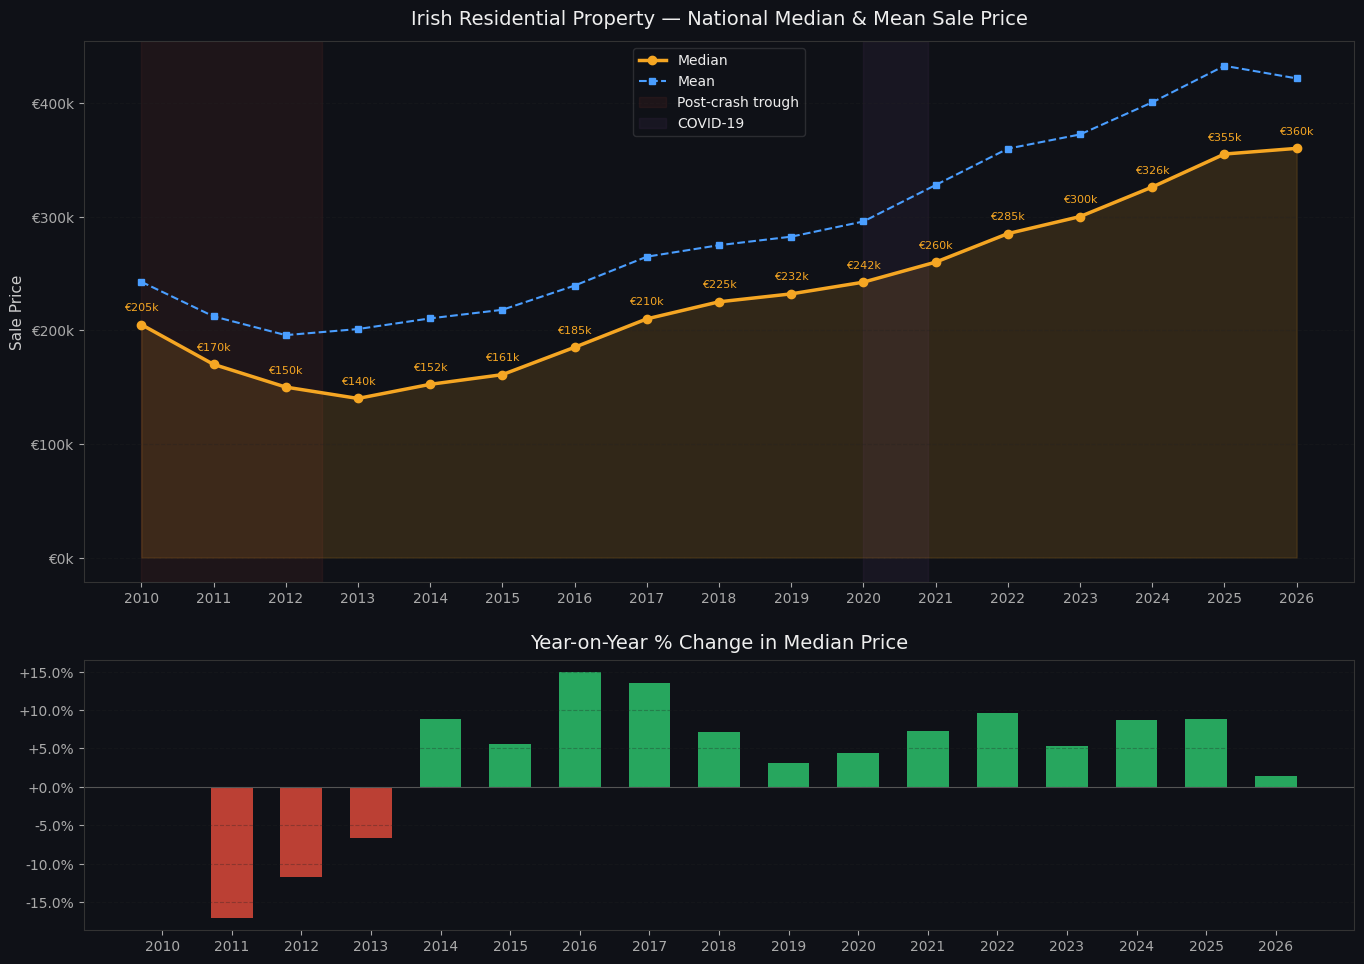

Peak year:    2026 — €360,000
Trough year:  2013 — €140,000
Latest year:  2026 — €360,000
Recovery:     +157.1% from trough


In [4]:
annual = df.groupby('year').agg(
    median_price=('price_eur', 'median'),
    mean_price=('price_eur', 'mean'),
    total_sales=('price_eur', 'count'),
    total_value=('price_eur', 'sum')
).reset_index()

annual['yoy_pct'] = annual['median_price'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Top: price trend
ax = axes[0]
ax.fill_between(annual['year'], annual['median_price'], alpha=0.15, color=ACCENT)
ax.plot(annual['year'], annual['median_price'], color=ACCENT, linewidth=2.5, marker='o', markersize=6, label='Median')
ax.plot(annual['year'], annual['mean_price'],   color=BLUE,   linewidth=1.5, linestyle='--', marker='s', markersize=4, label='Mean')

for _, row in annual.iterrows():
    ax.annotate(f'€{row["median_price"]/1000:.0f}k',
                (row['year'], row['median_price']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color=ACCENT)

ax.axvspan(2010, 2012.5, alpha=0.07, color=RED, label='Post-crash trough')
ax.axvspan(2020, 2020.9, alpha=0.07, color=PURPLE, label='COVID-19')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title('Irish Residential Property — National Median & Mean Sale Price', pad=12)
ax.set_ylabel('Sale Price')
ax.legend(framealpha=0.15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(annual['year'])

# Bottom: YoY % change
ax2 = axes[1]
colors = [GREEN if v >= 0 else RED for v in annual['yoy_pct'].fillna(0)]
ax2.bar(annual['year'], annual['yoy_pct'].fillna(0), color=colors, alpha=0.8, width=0.6)
ax2.axhline(0, color='#555', linewidth=0.8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.1f}%'))
ax2.set_title('Year-on-Year % Change in Median Price', pad=8)
ax2.set_xticks(annual['year'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(pad=2)
plt.savefig('national_price_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

peak   = annual.loc[annual['median_price'].idxmax()]
trough = annual.loc[annual['median_price'].idxmin()]
latest = annual.iloc[-1]
print(f"Peak year:    {int(peak['year'])} — €{peak['median_price']:,.0f}")
print(f"Trough year:  {int(trough['year'])} — €{trough['median_price']:,.0f}")
print(f"Latest year:  {int(latest['year'])} — €{latest['median_price']:,.0f}")
print(f"Recovery:     +{(latest['median_price']/trough['median_price']-1)*100:.1f}% from trough")

---
## 3. Transaction Volumes — The Crash in Context

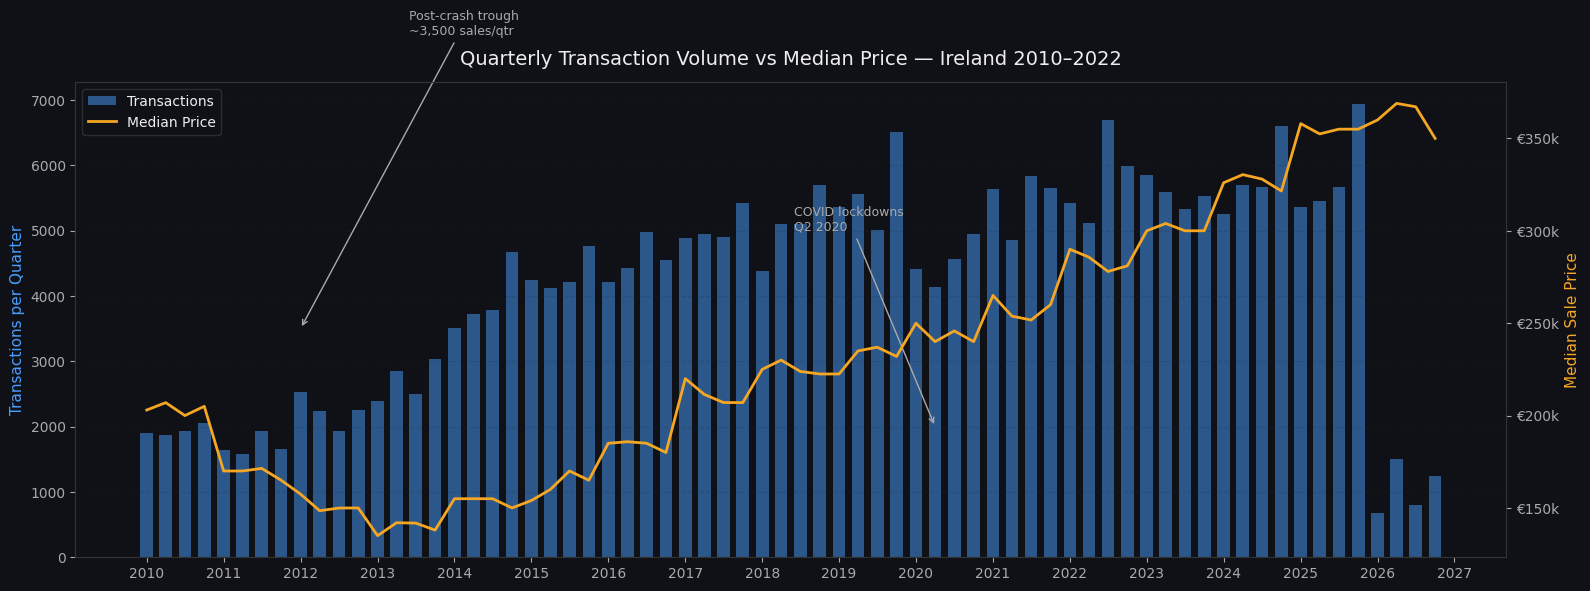

In [5]:
quarterly = df.groupby(df['date_of_sale'].dt.to_period('Q')).agg(
    sales=('price_eur', 'count'),
    median_price=('price_eur', 'median')
).reset_index()
quarterly['date'] = quarterly['date_of_sale'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(quarterly['date'], quarterly['sales'], width=60, color=BLUE, alpha=0.5, label='Transactions')
ax2.plot(quarterly['date'], quarterly['median_price'], color=ACCENT, linewidth=2, label='Median Price')

ax1.set_ylabel('Transactions per Quarter', color=BLUE)
ax2.set_ylabel('Median Sale Price', color=ACCENT)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))

# Annotations
ax1.annotate('Post-crash trough\n~3,500 sales/qtr', xy=(pd.Timestamp('2012-01-01'), 3500),
             xytext=(pd.Timestamp('2013-06-01'), 8000),
             arrowprops=dict(arrowstyle='->', color='#aaa'), color='#aaa', fontsize=9)
ax1.annotate('COVID lockdowns\nQ2 2020', xy=(pd.Timestamp('2020-04-01'), 2000),
             xytext=(pd.Timestamp('2018-06-01'), 5000),
             arrowprops=dict(arrowstyle='->', color='#aaa'), color='#aaa', fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.15)

ax1.set_title('Quarterly Transaction Volume vs Median Price — Ireland 2010–2022', pad=12)
ax1.grid(axis='y', alpha=0.2)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('quarterly_volumes.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 4. County-by-County Breakdown

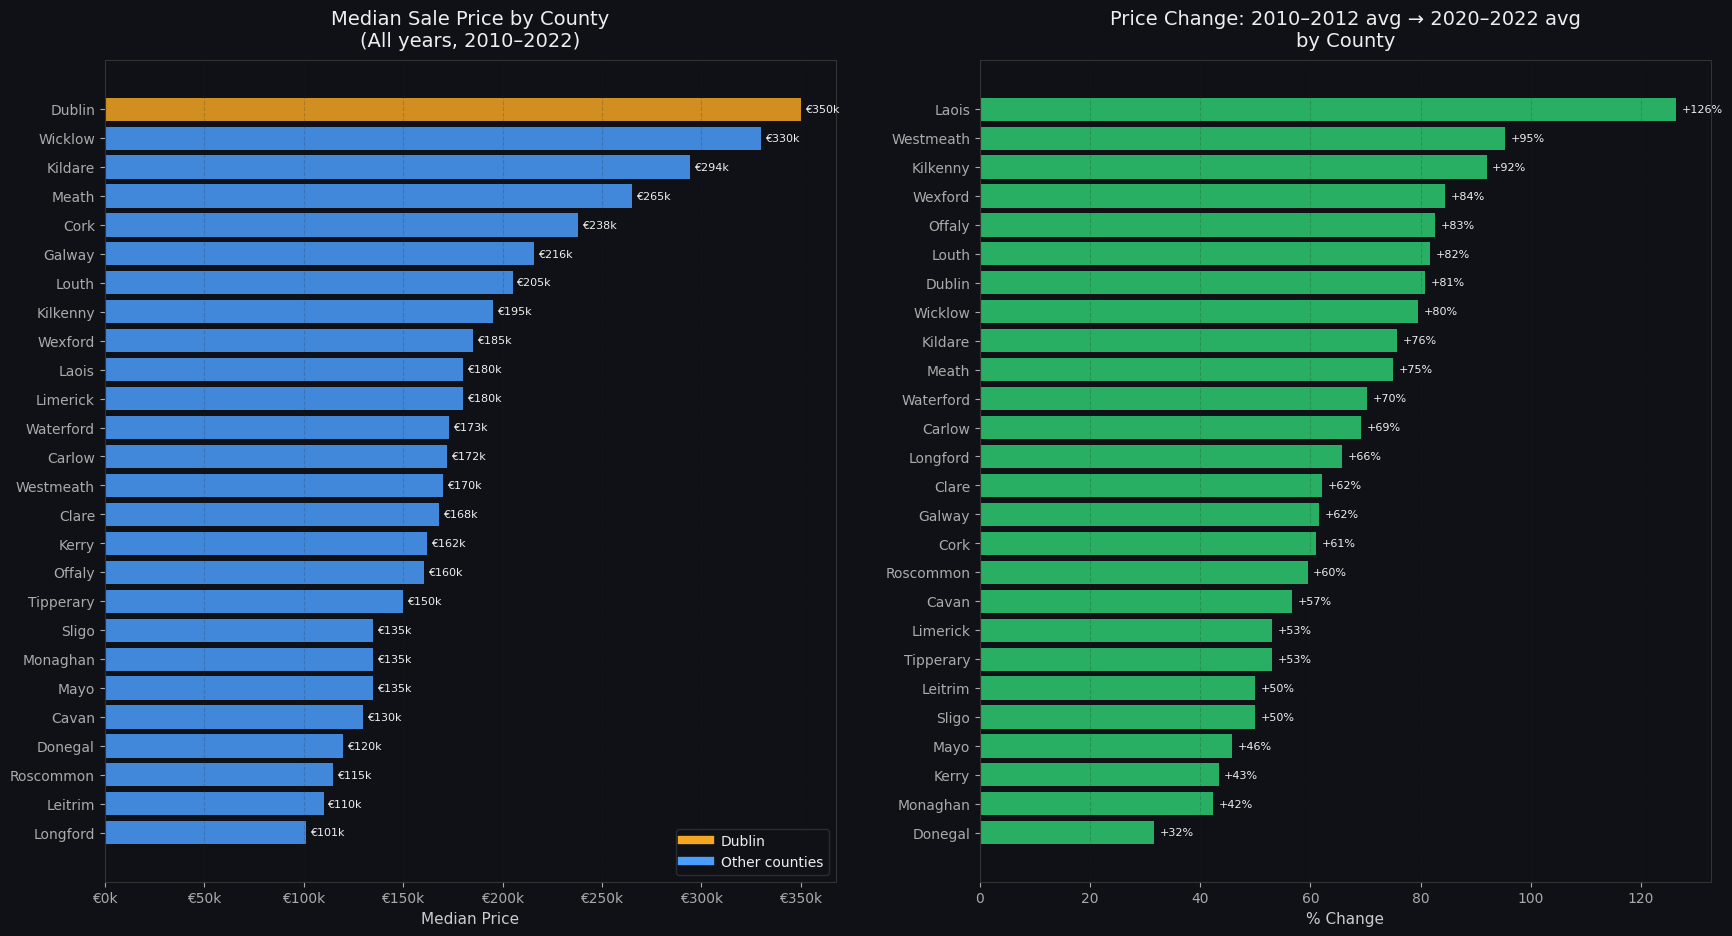

Top 5 most expensive counties (median):
county
Dublin     €350,000
Wicklow    €330,000
Kildare    €294,100
Meath      €265,000
Cork       €238,000
Name: median_price, dtype: object

Top 5 cheapest counties (median):
county
Longford     €101,000
Leitrim      €110,000
Roscommon    €115,000
Donegal      €120,000
Cavan        €130,000
Name: median_price, dtype: object


In [6]:
# Latest 3 years vs first 3 years for each county
recent = df[df['year'] >= 2020].groupby('county')['price_eur'].median().rename('recent')
early  = df[df['year'] <= 2012].groupby('county')['price_eur'].median().rename('early')
overall = df.groupby('county').agg(
    median_price=('price_eur', 'median'),
    total_sales=('price_eur', 'count')
)

county_stats = overall.join(recent).join(early)
county_stats['pct_change'] = (county_stats['recent'] / county_stats['early'] - 1) * 100
county_stats = county_stats.sort_values('median_price', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Left: median price ranking
ax = axes[0]
colors = [ACCENT if c == 'Dublin' else BLUE for c in county_stats.index]
bars = ax.barh(county_stats.index, county_stats['median_price'], color=colors, alpha=0.85)
for bar, val in zip(bars, county_stats['median_price']):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'€{val/1000:.0f}k', va='center', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title('Median Sale Price by County\n(All years, 2010–2022)', pad=10)
ax.set_xlabel('Median Price')
ax.grid(axis='x', alpha=0.2)
legend_els = [Line2D([0],[0],color=ACCENT,lw=6,label='Dublin'),
              Line2D([0],[0],color=BLUE,lw=6,label='Other counties')]
ax.legend(handles=legend_els, framealpha=0.15)

# Right: % change from 2010-2012 to 2020-2022
ax2 = axes[1]
chg = county_stats['pct_change'].dropna().sort_values(ascending=True)
bar_colors = [GREEN if v >= 0 else RED for v in chg]
ax2.barh(chg.index, chg.values, color=bar_colors, alpha=0.85)
for i, (county, val) in enumerate(chg.items()):
    ax2.text(val + (1 if val >= 0 else -1), i, f'{val:+.0f}%', va='center',
             ha='left' if val >= 0 else 'right', fontsize=8)
ax2.axvline(0, color='#555', linewidth=0.8)
ax2.set_title('Price Change: 2010–2012 avg → 2020–2022 avg\nby County', pad=10)
ax2.set_xlabel('% Change')
ax2.grid(axis='x', alpha=0.2)

plt.tight_layout(pad=3)
plt.savefig('county_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Top 5 most expensive counties (median):')
print(county_stats.sort_values('median_price', ascending=False)['median_price'].head().apply(lambda x: f'€{x:,.0f}'))
print('\nTop 5 cheapest counties (median):')
print(county_stats.sort_values('median_price')['median_price'].head().apply(lambda x: f'€{x:,.0f}'))

---
## 5. Dublin vs The Rest — The Capital Premium

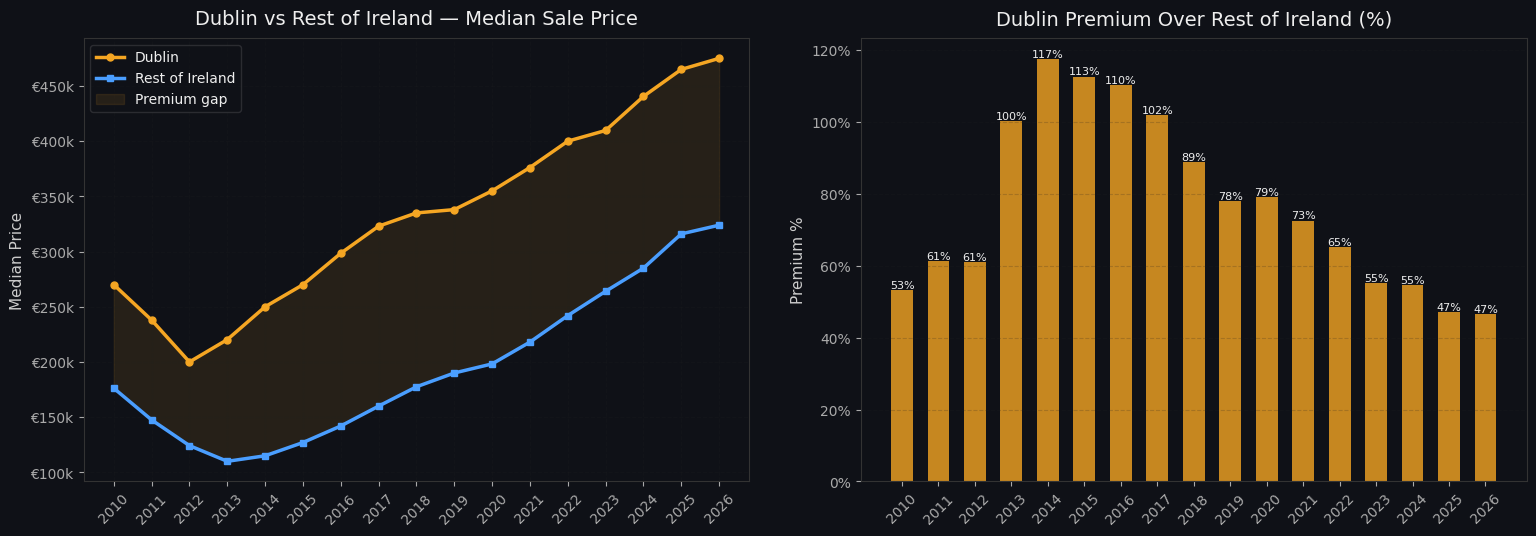

Dublin premium by year:
  2010: Dublin €270,000 | Rest €176,211 | Premium 53.2% (€93,789)
  2011: Dublin €237,943 | Rest €147,500 | Premium 61.3% (€90,443)
  2012: Dublin €200,000 | Rest €124,216 | Premium 61.0% (€75,784)
  2013: Dublin €220,264 | Rest €110,000 | Premium 100.2% (€110,264)
  2014: Dublin €250,000 | Rest €115,000 | Premium 117.4% (€135,000)
  2015: Dublin €270,000 | Rest €127,000 | Premium 112.6% (€143,000)
  2016: Dublin €298,462 | Rest €142,000 | Premium 110.2% (€156,462)
  2017: Dublin €323,000 | Rest €160,000 | Premium 101.9% (€163,000)
  2018: Dublin €335,000 | Rest €177,500 | Premium 88.7% (€157,500)
  2019: Dublin €338,000 | Rest €190,000 | Premium 77.9% (€148,000)
  2020: Dublin €355,000 | Rest €198,238 | Premium 79.1% (€156,762)
  2021: Dublin €376,138 | Rest €218,000 | Premium 72.5% (€158,138)
  2022: Dublin €400,000 | Rest €242,000 | Premium 65.3% (€158,000)
  2023: Dublin €409,692 | Rest €264,000 | Premium 55.2% (€145,692)
  2024: Dublin €440,529 | Rest €285,

In [7]:
dublin_vs_rest = df.groupby(['year', 'is_dublin'])['price_eur'].median().unstack()
dublin_vs_rest.columns = ['Rest of Ireland', 'Dublin']
dublin_vs_rest['premium_pct'] = (dublin_vs_rest['Dublin'] / dublin_vs_rest['Rest of Ireland'] - 1) * 100
dublin_vs_rest['premium_eur'] = dublin_vs_rest['Dublin'] - dublin_vs_rest['Rest of Ireland']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(dublin_vs_rest.index, dublin_vs_rest['Dublin'],         color=ACCENT, lw=2.5, marker='o', markersize=5, label='Dublin')
ax.plot(dublin_vs_rest.index, dublin_vs_rest['Rest of Ireland'],color=BLUE,   lw=2.5, marker='s', markersize=5, label='Rest of Ireland')
ax.fill_between(dublin_vs_rest.index,
                dublin_vs_rest['Rest of Ireland'],
                dublin_vs_rest['Dublin'],
                alpha=0.1, color=ACCENT, label='Premium gap')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title('Dublin vs Rest of Ireland — Median Sale Price', pad=10)
ax.set_ylabel('Median Price')
ax.legend(framealpha=0.15)
ax.grid(alpha=0.2)
ax.set_xticks(dublin_vs_rest.index)
ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.bar(dublin_vs_rest.index, dublin_vs_rest['premium_pct'], color=ACCENT, alpha=0.8, width=0.6)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_title('Dublin Premium Over Rest of Ireland (%)', pad=10)
ax2.set_ylabel('Premium %')
ax2.grid(axis='y', alpha=0.2)
ax2.set_xticks(dublin_vs_rest.index)
ax2.tick_params(axis='x', rotation=45)
for i, (yr, row) in enumerate(dublin_vs_rest.iterrows()):
    ax2.text(yr, row['premium_pct'] + 0.5, f"{row['premium_pct']:.0f}%",
             ha='center', fontsize=8)

plt.tight_layout(pad=3)
plt.savefig('dublin_vs_rest.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Dublin premium by year:')
for yr, row in dublin_vs_rest.iterrows():
    print(f"  {int(yr)}: Dublin €{row['Dublin']:,.0f} | Rest €{row['Rest of Ireland']:,.0f} | "
          f"Premium {row['premium_pct']:.1f}% (€{row['premium_eur']:,.0f})")

---
## 6. New Builds vs Second-Hand

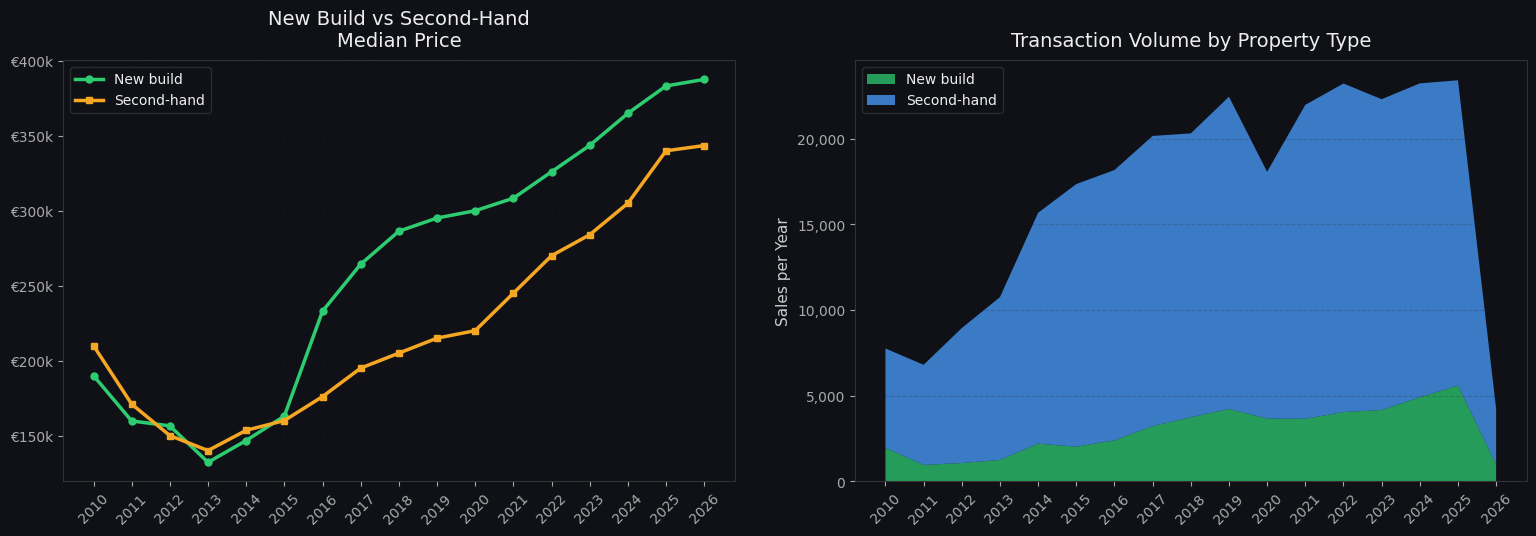

New build share of market by year:
  2010: 25.2% new builds | Median new €190,000 | Median second-hand €210,000
  2011: 14.2% new builds | Median new €159,746 | Median second-hand €171,000
  2012: 12.0% new builds | Median new €156,486 | Median second-hand €150,000
  2013: 11.7% new builds | Median new €132,159 | Median second-hand €140,000
  2014: 14.1% new builds | Median new €146,696 | Median second-hand €153,500
  2015: 11.7% new builds | Median new €162,996 | Median second-hand €160,012
  2016: 13.2% new builds | Median new €233,000 | Median second-hand €176,000
  2017: 16.0% new builds | Median new €264,317 | Median second-hand €195,000
  2018: 18.4% new builds | Median new €286,344 | Median second-hand €205,000
  2019: 18.8% new builds | Median new €295,153 | Median second-hand €215,000
  2020: 20.3% new builds | Median new €300,000 | Median second-hand €220,000
  2021: 16.6% new builds | Median new €308,370 | Median second-hand €245,000
  2022: 17.4% new builds | Median new €32

In [8]:
build_annual = df.groupby(['year', 'is_new']).agg(
    median_price=('price_eur', 'median'),
    count=('price_eur', 'count')
).unstack()

build_annual.columns = ['_'.join([str(c) for c in col]) for col in build_annual.columns]
build_annual = build_annual.rename(columns={
    'median_price_False': 'second_hand_price',
    'median_price_True':  'new_build_price',
    'count_False':        'second_hand_count',
    'count_True':         'new_build_count',
})
build_annual['new_pct'] = build_annual['new_build_count'] / \
    (build_annual['new_build_count'] + build_annual['second_hand_count']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(build_annual.index, build_annual['new_build_price'],   color=GREEN,  lw=2.5, marker='o', markersize=5, label='New build')
ax.plot(build_annual.index, build_annual['second_hand_price'], color=ACCENT, lw=2.5, marker='s', markersize=5, label='Second-hand')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title('New Build vs Second-Hand\nMedian Price', pad=10)
ax.legend(framealpha=0.15)
ax.grid(alpha=0.2)
ax.set_xticks(build_annual.index)
ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.stackplot(build_annual.index,
              build_annual['new_build_count'],
              build_annual['second_hand_count'],
              labels=['New build', 'Second-hand'],
              colors=[GREEN, BLUE], alpha=0.75)
ax2.set_title('Transaction Volume by Property Type', pad=10)
ax2.set_ylabel('Sales per Year')
ax2.legend(framealpha=0.15)
ax2.grid(axis='y', alpha=0.2)
ax2.set_xticks(build_annual.index)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout(pad=3)
plt.savefig('new_vs_secondhand.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('New build share of market by year:')
for yr, row in build_annual.iterrows():
    print(f"  {int(yr)}: {row['new_pct']:.1f}% new builds | "
          f"Median new €{row['new_build_price']:,.0f} | "
          f"Median second-hand €{row['second_hand_price']:,.0f}")

---
## 7. COVID Impact — 2019 vs 2020 vs 2021

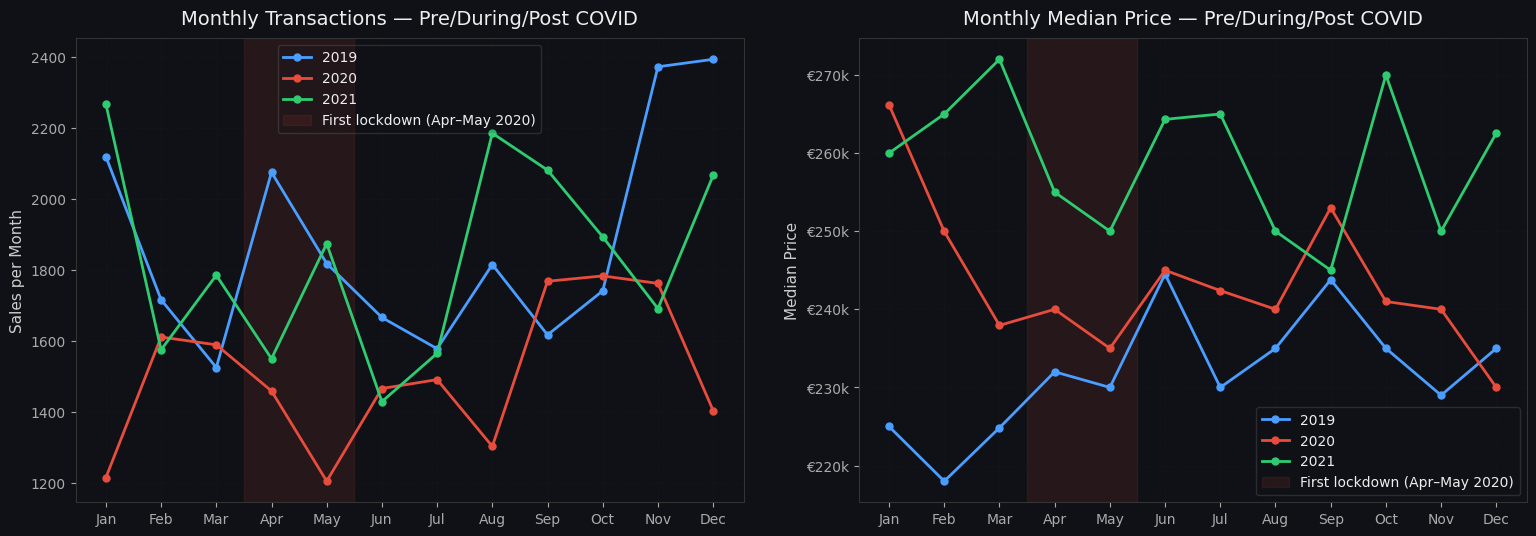

  April 2019: 2,076 sales | Median €232,000
  April 2020: 1,460 sales | Median €240,000
  April 2021: 1,551 sales | Median €255,000


In [9]:
covid_df = df[df['year'].isin([2019, 2020, 2021])].copy()
monthly_covid = covid_df.groupby(['year', 'month']).agg(
    sales=('price_eur', 'count'),
    median_price=('price_eur', 'median')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
year_colors = {2019: BLUE, 2020: RED, 2021: GREEN}

for yr in [2019, 2020, 2021]:
    yd = monthly_covid[monthly_covid['year'] == yr]
    axes[0].plot(yd['month'], yd['sales'],        color=year_colors[yr], lw=2, marker='o', markersize=5, label=str(yr))
    axes[1].plot(yd['month'], yd['median_price'], color=year_colors[yr], lw=2, marker='o', markersize=5, label=str(yr))

# Lockdown shading — Ireland's first lockdown April-May 2020
for ax in axes:
    ax.axvspan(3.5, 5.5, alpha=0.1, color=RED, label='First lockdown (Apr–May 2020)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.legend(framealpha=0.15)
    ax.grid(alpha=0.2)

axes[0].set_title('Monthly Transactions — Pre/During/Post COVID', pad=10)
axes[0].set_ylabel('Sales per Month')
axes[1].set_title('Monthly Median Price — Pre/During/Post COVID', pad=10)
axes[1].set_ylabel('Median Price')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))

plt.tight_layout(pad=3)
plt.savefig('covid_impact.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# April volume drop
for yr in [2019, 2020, 2021]:
    apr = monthly_covid[(monthly_covid['year']==yr) & (monthly_covid['month']==4)]
    if not apr.empty:
        print(f"  April {yr}: {apr['sales'].values[0]:,} sales | Median €{apr['median_price'].values[0]:,.0f}")

---
## 8. Seasonal Patterns — When Do Irish People Buy Houses?

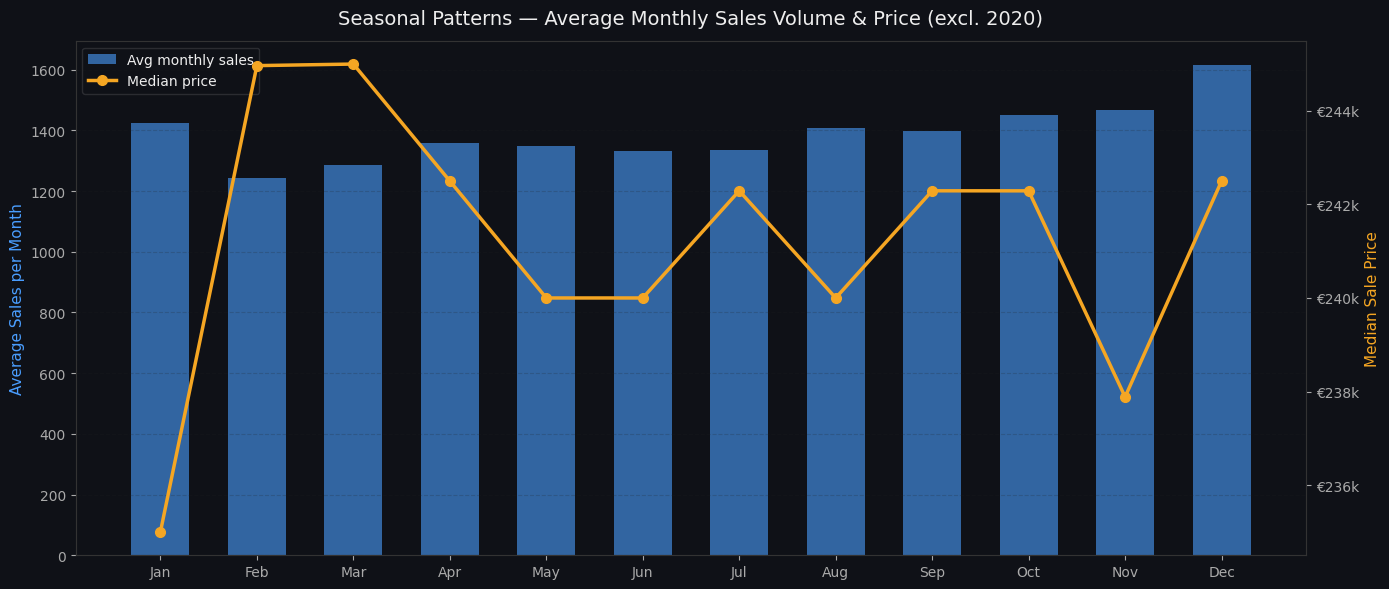

Busiest month:   Dec (1615 avg sales/year)
Quietest month:  Feb (1244 avg sales/year)
Highest prices:  Mar (median €245,000)


In [10]:
# Exclude 2020 (COVID distortion)
seasonal = df[df['year'] != 2020].groupby('month').agg(
    avg_sales=('price_eur', 'count'),
    median_price=('price_eur', 'median')
).reset_index()
# Normalise sales by number of years
n_years = df[df['year'] != 2020]['year'].nunique()
seasonal['avg_sales'] = seasonal['avg_sales'] / n_years

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(seasonal['month'], seasonal['avg_sales'], color=BLUE, alpha=0.6, width=0.6, label='Avg monthly sales')
ax2.plot(seasonal['month'], seasonal['median_price'], color=ACCENT, lw=2.5, marker='o', markersize=7, label='Median price')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.set_ylabel('Average Sales per Month', color=BLUE)
ax2.set_ylabel('Median Sale Price', color=ACCENT)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax1.set_title('Seasonal Patterns — Average Monthly Sales Volume & Price (excl. 2020)', pad=12)
ax1.grid(axis='y', alpha=0.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, framealpha=0.15)

plt.tight_layout()
plt.savefig('seasonal_patterns.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

busiest = seasonal.loc[seasonal['avg_sales'].idxmax()]
quietest = seasonal.loc[seasonal['avg_sales'].idxmin()]
priciest = seasonal.loc[seasonal['median_price'].idxmax()]
print(f"Busiest month:   {month_names[int(busiest['month'])-1]} ({busiest['avg_sales']:.0f} avg sales/year)")
print(f"Quietest month:  {month_names[int(quietest['month'])-1]} ({quietest['avg_sales']:.0f} avg sales/year)")
print(f"Highest prices:  {month_names[int(priciest['month'])-1]} (median €{priciest['median_price']:,.0f})")

---
## 9. Dublin Eircode Analysis — Which Postcodes Are Most Expensive?

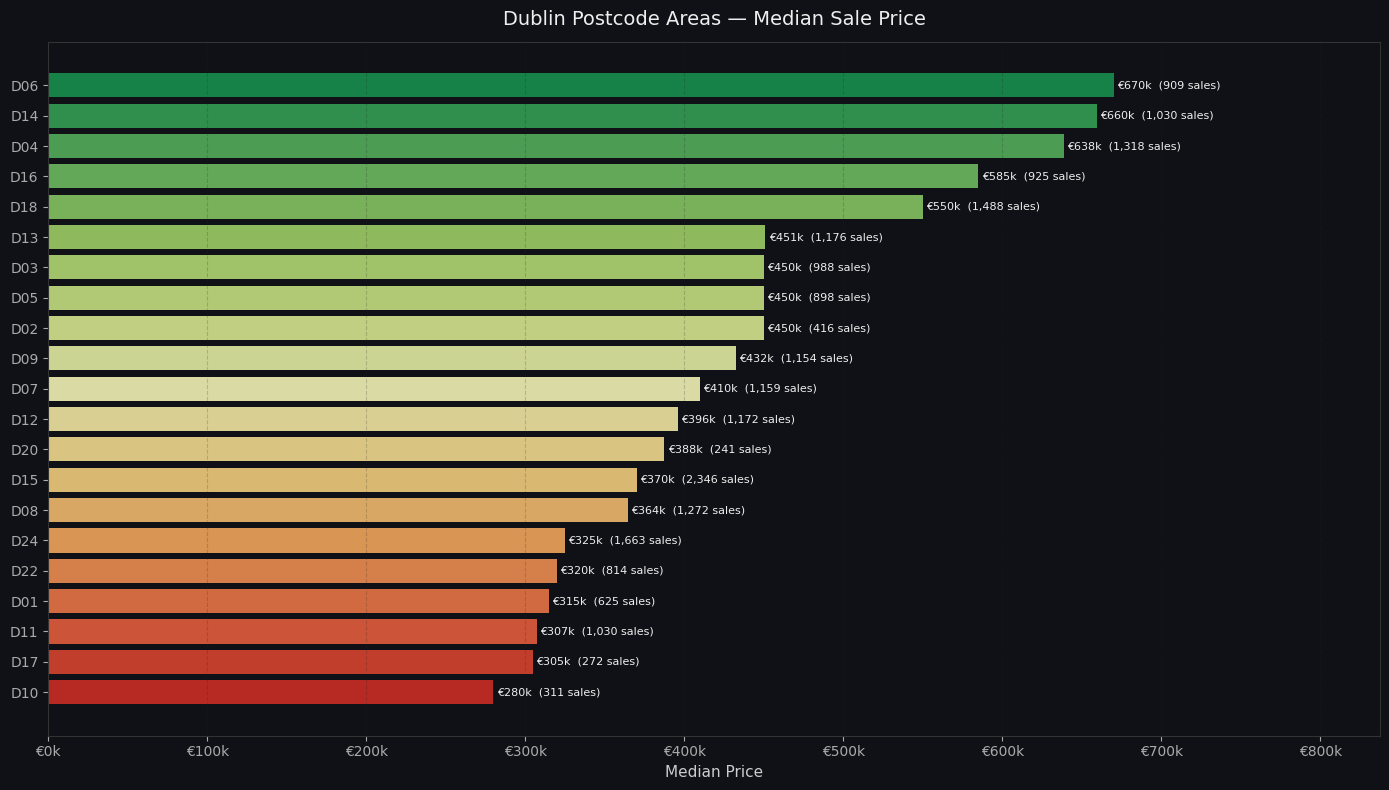

Top 5 most expensive Dublin postcodes:
postcode  median_price  total_sales
     D06      670000.0          909
     D14      659500.0         1030
     D04      638500.0         1318
     D16      585000.0          925
     D18      550000.0         1488

Top 5 most affordable Dublin postcodes:
postcode  median_price  total_sales
     D10      280000.0          311
     D17      304750.0          272
     D11      307250.0         1030
     D01      315000.0          625
     D22      320000.0          814


In [11]:
dublin_df = df[
    (df['county'] == 'Dublin') &
    (df['eircode'].notna()) &
    (df['eircode'].str.startswith('D'))
].copy()

# Extract Dublin postcode prefix (D01, D02, ... D24)
dublin_df['postcode'] = dublin_df['eircode'].str[:3]

# Keep only D01–D24 (standard Dublin postcodes)
valid_postcodes = [f'D{n:02d}' for n in range(1, 25)]
dublin_df = dublin_df[dublin_df['postcode'].isin(valid_postcodes)]

eircode_stats = dublin_df.groupby('postcode').agg(
    median_price=('price_eur', 'median'),
    total_sales=('price_eur', 'count')
).reset_index().sort_values('median_price', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(eircode_stats)))
bars = ax.barh(eircode_stats['postcode'], eircode_stats['median_price'], color=colors, alpha=0.85)

for bar, (_, row) in zip(bars, eircode_stats.iterrows()):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f"€{row['median_price']/1000:.0f}k  ({row['total_sales']:,} sales)",
            va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title('Dublin Postcode Areas — Median Sale Price', pad=12)
ax.set_xlabel('Median Price')
ax.grid(axis='x', alpha=0.2)
ax.set_xlim(0, eircode_stats['median_price'].max() * 1.25)

plt.tight_layout()
plt.savefig('dublin_eircode.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Top 5 most expensive Dublin postcodes:')
print(eircode_stats.sort_values('median_price', ascending=False).head()[['postcode','median_price','total_sales']].to_string(index=False))
print('\nTop 5 most affordable Dublin postcodes:')
print(eircode_stats.head()[['postcode','median_price','total_sales']].to_string(index=False))

---
## 10. Price Heatmap — County × Year

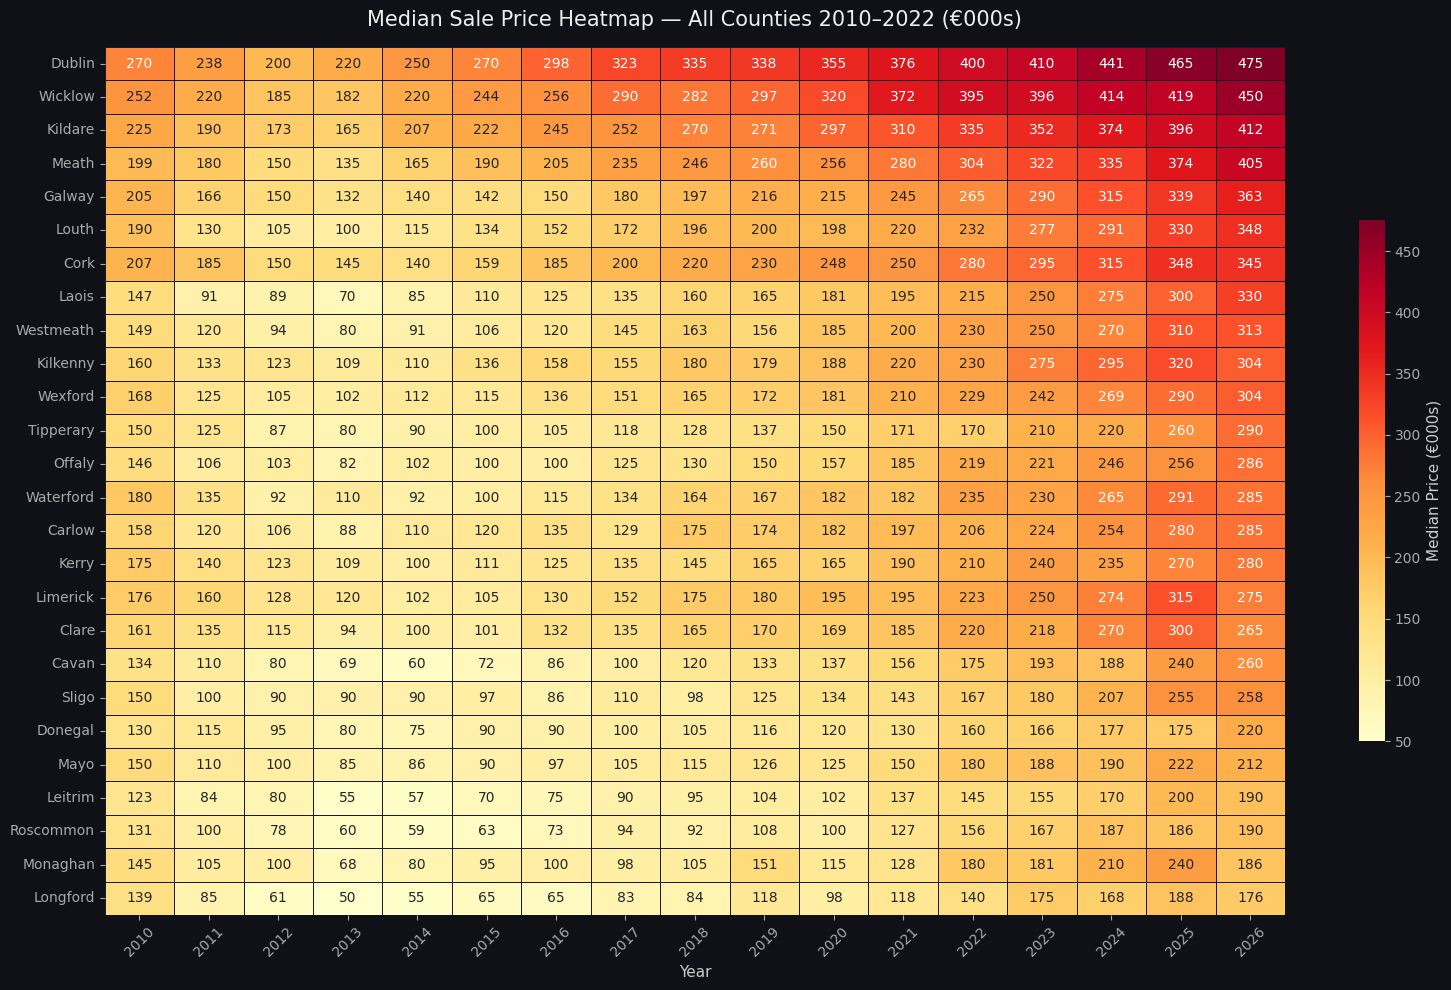

In [12]:
pivot = df.groupby(['county', 'year'])['price_eur'].median().unstack()

# Sort counties by 2022 median
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot / 1000,
    ax=ax,
    cmap='YlOrRd',
    fmt='.0f',
    annot=True,
    linewidths=0.4,
    linecolor='#1a1a2e',
    cbar_kws={'label': 'Median Price (€000s)', 'shrink': 0.6}
)

ax.set_title('Median Sale Price Heatmap — All Counties 2010–2022 (€000s)', pad=15, fontsize=15)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('county_year_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 11. Non-Market Sales — Family Transfers & Below-Market Deals

Non-market price sales: 14,089 (4.9% of all sales)
Median price (non-market): €144,000
Median price (market):     €247,500
Discount implied:          41.8%


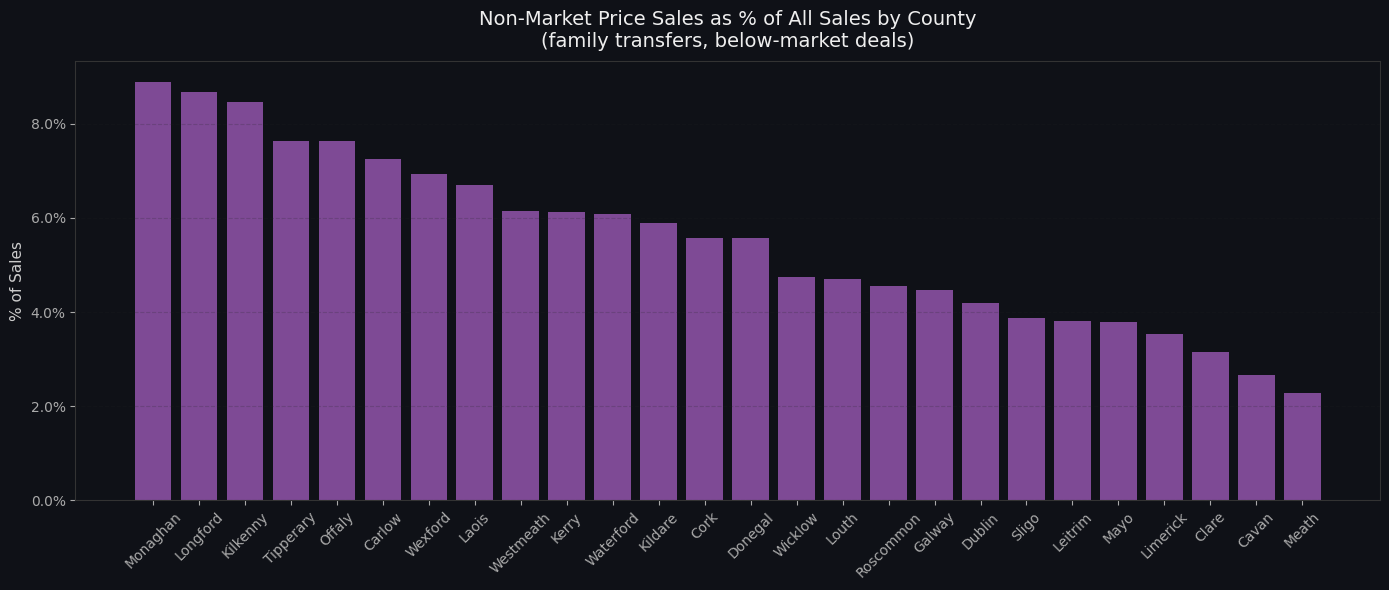

In [13]:
non_market = df[df['not_full_market_price'] == True]
market     = df[df['not_full_market_price'] == False]

print(f"Non-market price sales: {len(non_market):,} ({len(non_market)/len(df)*100:.1f}% of all sales)")
print(f"Median price (non-market): €{non_market['price_eur'].median():,.0f}")
print(f"Median price (market):     €{market['price_eur'].median():,.0f}")
print(f"Discount implied:          {(1 - non_market['price_eur'].median()/market['price_eur'].median())*100:.1f}%")

nm_by_county = non_market.groupby('county').size() / df.groupby('county').size() * 100
nm_by_county = nm_by_county.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(nm_by_county.index, nm_by_county.values, color=PURPLE, alpha=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title('Non-Market Price Sales as % of All Sales by County\n(family transfers, below-market deals)', pad=10)
ax.set_ylabel('% of Sales')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('non_market_sales.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 12. Key Findings Summary

In [14]:
# Pull together the headline numbers
median_2010 = df[df['year']==2010]['price_eur'].median()
median_2022 = df[df['year']==2022]['price_eur'].median()
median_trough = df.groupby('year')['price_eur'].median().min()
trough_year = int(df.groupby('year')['price_eur'].median().idxmin())
sales_2010  = len(df[df['year']==2010])
sales_2022  = len(df[df['year']==2022])
total_value = df['price_eur'].sum()
dub_2022 = df[(df['year']==2022) & (df['county']=='Dublin')]['price_eur'].median()
roi_2022 = df[(df['year']==2022) & (df['county']!='Dublin')]['price_eur'].median()

print('=' * 55)
print('  IRISH PROPERTY MARKET — KEY FINDINGS 2010–2022')
print('=' * 55)
print(f'  Total transactions:     {len(df):>12,}')
print(f'  Total market value:     €{total_value/1e9:>10.1f}bn')
print(f'  National median (2010): €{median_2010:>10,.0f}')
print(f'  National median (2022): €{median_2022:>10,.0f}')
print(f'  Change 2010→2022:       {(median_2022/median_2010-1)*100:>+10.1f}%')
print(f'  Trough year:            {trough_year:>12} (€{median_trough:,.0f})')
print(f'  Recovery from trough:   {(median_2022/median_trough-1)*100:>+10.1f}%')
print(f'  Dublin median (2022):   €{dub_2022:>10,.0f}')
print(f'  Rest of IRE (2022):     €{roi_2022:>10,.0f}')
print(f'  Dublin premium (2022):  {(dub_2022/roi_2022-1)*100:>+10.1f}%')
print(f'  Sales volume (2010):    {sales_2010:>12,}')
print(f'  Sales volume (2022):    {sales_2022:>12,}')
print('=' * 55)
print()

  IRISH PROPERTY MARKET — KEY FINDINGS 2010–2022
  Total transactions:          284,817
  Total market value:     €      86.3bn
  National median (2010): €   205,000
  National median (2022): €   285,000
  Change 2010→2022:            +39.0%
  Trough year:                    2013 (€140,000)
  Recovery from trough:       +103.6%
  Dublin median (2022):   €   400,000
  Rest of IRE (2022):     €   242,000
  Dublin premium (2022):       +65.3%
  Sales volume (2010):           7,759
  Sales volume (2022):          23,221



---

## Notes

- Prices are nominal (not inflation-adjusted).
- `not_full_market_price = TRUE` rows are included in all analyses. Filter them out for pure open-market comparisons.
- Eircode coverage is incomplete for early years (pre-2015) — eircode analysis is weighted toward more recent sales.
- The register records the date of **filing**, not necessarily the date of **closing** — there can be a lag of several weeks.

**Source:** Revenue Commissioners / PSRA Property Price Register — PSI open licence. Redistributed under CC BY 4.0.